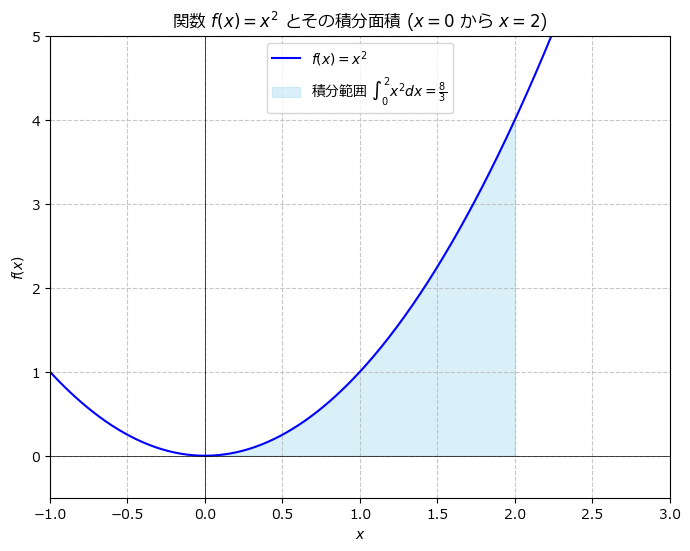

In [42]:
#41
import matplotlib.pyplot as plt
import numpy as np

# グラフの設定
plt.rcParams['font.family'] = 'Meiryo' # Windowsの場合、Meiryo UI なども可
plt.figure(figsize=(8, 6))

# xの範囲を設定
x = np.linspace(-1, 3, 400)
y = x**2

# 関数 y=x^2 をプロット
plt.plot(x, y, label='$f(x) = x^2$', color='blue')

# 積分範囲の設定
x_fill = np.linspace(0, 2, 100)
y_fill = x_fill**2

# 積分範囲を塗りつぶし (ハッチング)
plt.fill_between(x_fill, y_fill, alpha=0.3, color='skyblue', label='積分範囲 $\\int_{0}^{2} x^2 dx = \\frac{8}{3}$')
# plt.fill_between(x_fill, y_fill, hatch='//', edgecolor='dodgerblue', facecolor='skyblue', alpha=0.5, label='積分範囲 $\int_{0}^{2} x^2 dx = \\frac{8}{3}$') # ハッチングの別例

# 軸とグリッドの設定
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.7)

# ラベルとタイトルの設定
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.title('関数 $f(x) = x^2$ とその積分面積 ($x=0$ から $x=2$)')
plt.legend()

# 表示範囲の調整 (任意)
plt.xlim(-1, 3)
plt.ylim(-0.5, 5) # y=x^2 なので、x=2 で y=4。少し余裕を持たせる。

# グラフの表示
plt.show()

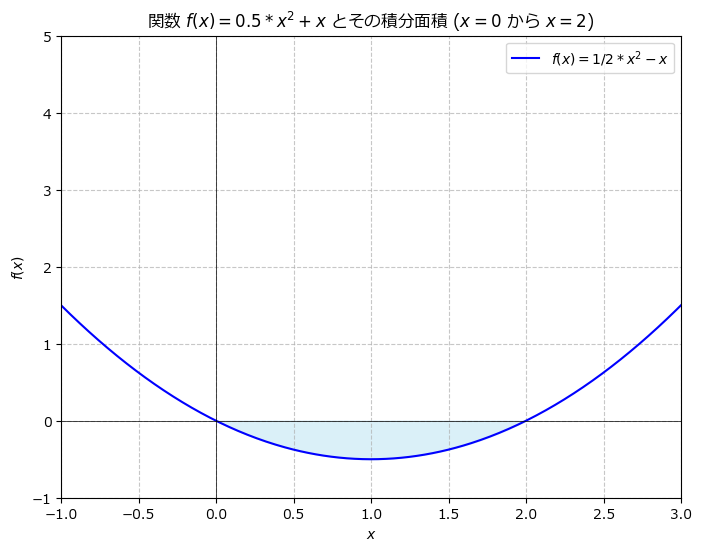

In [ ]:
#42
plt.rcParams['font.family'] = 'Meiryo' # Windowsの場合、Meiryo UI なども可
plt.figure(figsize=(8, 6))

# xの範囲を設定
x = np.linspace(-1, 3, 400)
y = 1/2*x*x-x

# 関数 をプロット
plt.plot(x, y, label='$f(x) = 1/2*x^2-x$', color='blue')

# 積分範囲の設定
x_fill = np.linspace(0, 2, 100)
y_fill = 0.5*x_fill**2-x_fill

# 積分範囲を塗りつぶし (ハッチング)
plt.fill_between(x_fill, y_fill, alpha=0.3, color='skyblue')

# 軸とグリッドの設定
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.7)

# ラベルとタイトルの設定
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.title('関数 $f(x) = 0.5*x^2+x$ とその積分面積 ($x=0$ から $x=2$)')
plt.legend()

# 表示範囲の調整 (任意)
plt.xlim(-1, 3)
plt.ylim(-1, 5) # y=x^2 なので、x=2 で y=4。少し余裕を持たせる。

# グラフの表示
plt.show()

面積 = 9/2


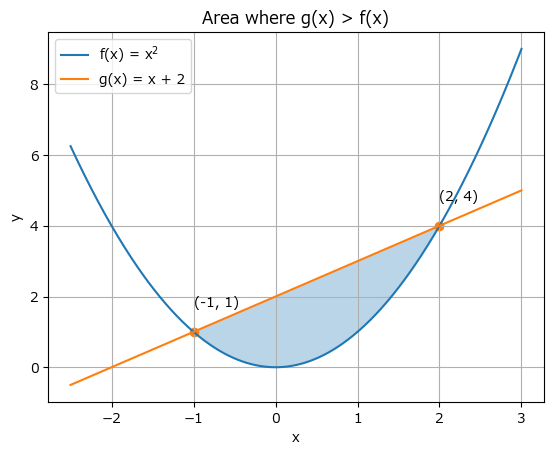

In [44]:
#43
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# ------------------------------------------------------------------
# 1. symbolic part – 求積
x = sp.symbols('x')
f = x**2
g = x + 2
area = sp.integrate(g - f, (x, -1, 2))  # ∫_{-1}^{2} (x+2 - x^2) dx
print(f"面積 = {area}")  # sympy は分数で返すので確認用に表示

# ------------------------------------------------------------------
# 2. visualisation
def f_val(x_arr):
    return x_arr ** 2

def g_val(x_arr):
    return x_arr + 2

# 描画範囲を少し広めに
x_plot = np.linspace(-2.5, 3.0, 400)
y_f = f_val(x_plot)
y_g = g_val(x_plot)

plt.plot(x_plot, y_f, label="f(x) = x$^{2}$")
plt.plot(x_plot, y_g, label="g(x) = x + 2")

# 塗りつぶし (–1, 2) の区間で g ≥ f
x_fill = np.linspace(-1.0, 2.0, 300)
plt.fill_between(x_fill, g_val(x_fill), f_val(x_fill), where=g_val(x_fill) >= f_val(x_fill), alpha=0.3)

# 交点をマーク
plt.scatter([-1, 2], [f_val(-1), f_val(2)])
plt.text(-1, f_val(-1) + 0.7, "(-1, 1)")
plt.text( 2, f_val(2) + 0.7, "(2, 4)")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Area where g(x) > f(x)")
plt.legend()
plt.grid(True)
plt.show()


In [45]:
#44
x=sp.Symbol('x')
y=x*x
v=sp.pi*sp.integrate(y**2,(x,0,1))
print(v)


pi/5


In [ ]:
#45
y=sp.Symbol('y')
v=2*sp.pi*sp.integrate(y*(1-y**0.5),(y,0,1))
print(v)

0.2*pi


In [47]:
#46
import sympy as sp

# 変数 x を定義
x = sp.Symbol('x', real=True)

# 標準正規分布の確率密度関数
pdf = 1/sp.sqrt(2*sp.pi) * sp.exp(-x**2/2)

# -1 から 1 まで積分して数値化
res = sp.integrate(pdf, (x, -1, 1)).evalf()

print("数値積分の結果 =", res)


数値積分の結果 = 0.682689492137086


In [55]:
#47
import numpy as np
import sympy as sp # SymPyライブラリをspとしてインポート

x = sp.Symbol('x')
f = sp.sin(x)
# lambdifyの第1引数にシンボルxを、第2引数に式fを指定
f_l = sp.lambdify(x, f, 'numpy')
r=[]
for n in range(1, 20):
    # np.linspaceの第2引数にnp.piを使用
    x_vals = np.linspace(0, np.pi, 2**n)

    # f(x) の値を計算
    f_vals = f_l(x_vals)

    # 台形則で数値積分
    # numpy の trapz 関数は台形則による数値積分を計算するユーティリティ
    integral_approx = np.trapz(f_vals, x_vals)
    r.append(integral_approx)
    print(f"n = {2**n:2d} (分割数), 近似結果 = {integral_approx:.8f}, 誤差 = {abs(integral_approx - 2.0):.8f}")

n =  2 (分割数), 近似結果 = 0.00000000, 誤差 = 2.00000000
n =  4 (分割数), 近似結果 = 1.81379936, 誤差 = 0.18620064
n =  8 (分割数), 近似結果 = 1.96631668, 誤差 = 0.03368332
n = 16 (分割数), 近似結果 = 1.99268383, 誤差 = 0.00731617
n = 32 (分割数), 近似結果 = 1.99828802, 誤差 = 0.00171198
n = 64 (分割数), 近似結果 = 1.99958554, 誤差 = 0.00041446
n = 128 (分割数), 近似結果 = 1.99989801, 誤差 = 0.00010199
n = 256 (分割数), 近似結果 = 1.99997470, 誤差 = 0.00002530
n = 512 (分割数), 近似結果 = 1.99999370, 誤差 = 0.00000630
n = 1024 (分割数), 近似結果 = 1.99999843, 誤差 = 0.00000157
n = 2048 (分割数), 近似結果 = 1.99999961, 誤差 = 0.00000039
n = 4096 (分割数), 近似結果 = 1.99999990, 誤差 = 0.00000010
n = 8192 (分割数), 近似結果 = 1.99999998, 誤差 = 0.00000002
n = 16384 (分割数), 近似結果 = 1.99999999, 誤差 = 0.00000001
n = 32768 (分割数), 近似結果 = 2.00000000, 誤差 = 0.00000000
n = 65536 (分割数), 近似結果 = 2.00000000, 誤差 = 0.00000000
n = 131072 (分割数), 近似結果 = 2.00000000, 誤差 = 0.00000000
n = 262144 (分割数), 近似結果 = 2.00000000, 誤差 = 0.00000000
n = 524288 (分割数), 近似結果 = 2.00000000, 誤差 = 0.00000000


C:\Users\katet\AppData\Local\Temp\ipykernel_5540\1975349177.py:18: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_approx = np.trapz(f_vals, x_vals)


In [64]:
#48
import numpy as np
from scipy.integrate import simpson

def f_sin(x):
    """標準正規分布の確率密度関数"""
    return np.sin(x)
r2=[]
# 積分区間
# N は偶数が望ましい（scipy.integrate.simpsは奇数でもうまくやってくれますが、理論上は偶数）
for n in range(1,20):

# 等差数列
    x_vals = np.linspace(0, np.pi, 2**n)
    f_vals = f_sin(x_vals)
# シンプソン則による近似
    result = simpson(f_vals, x_vals)
    r2.append(result)
i=1
for d,s in zip(r,r2):
    print(f"n = {2**i:2d} (分割数), 近似結果 = {d:.8f}, 近似結果 = {s:.8f},差分 = {abs(d-s):.8f}")
    i+=1

n =  2 (分割数), 近似結果 = 0.00000000, 近似結果 = 0.00000000,差分 = 0.00000000
n =  4 (分割数), 近似結果 = 1.81379936, 近似結果 = 2.04052428,差分 = 0.22672492
n =  8 (分割数), 近似結果 = 1.96631668, 近似結果 = 2.00198511,差分 = 0.03566843
n = 16 (分割数), 近似結果 = 1.99268383, 近似結果 = 2.00009991,差分 = 0.00741608
n = 32 (分割数), 近似結果 = 1.99828802, 近似結果 = 2.00000555,差分 = 0.00171753
n = 64 (分割数), 近似結果 = 1.99958554, 近似結果 = 2.00000033,差分 = 0.00041479
n = 128 (分割数), 近似結果 = 1.99989801, 近似結果 = 2.00000002,差分 = 0.00010201
n = 256 (分割数), 近似結果 = 1.99997470, 近似結果 = 2.00000000,差分 = 0.00002530
n = 512 (分割数), 近似結果 = 1.99999370, 近似結果 = 2.00000000,差分 = 0.00000630
n = 1024 (分割数), 近似結果 = 1.99999843, 近似結果 = 2.00000000,差分 = 0.00000157
n = 2048 (分割数), 近似結果 = 1.99999961, 近似結果 = 2.00000000,差分 = 0.00000039
n = 4096 (分割数), 近似結果 = 1.99999990, 近似結果 = 2.00000000,差分 = 0.00000010
n = 8192 (分割数), 近似結果 = 1.99999998, 近似結果 = 2.00000000,差分 = 0.00000002
n = 16384 (分割数), 近似結果 = 1.99999999, 近似結果 = 2.00000000,差分 = 0.00000001
n = 32768 (分割数), 近似結果 = 2.00000000, 近似結果 = 2.000

In [66]:
#49
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, Dropdown

# 積分対象の関数
def f(x):
    return x**2

# 積分区間 [a, b]
a = 0
b = 2

# 真の積分値 (比較のため)
# ∫[0,2] x^2 dx = [x^3/3]_0^2 = 8/3
integral_true = (b**3 / 3) - (a**3 / 3)

def plot_riemann_sum_interactive(n, method):
    """
    リーマン和を計算し、インタラクティブにグラフ描画する関数。

    Parameters:
    n (int): 小区間の分割数
    method (str): リーマン和の手法 ('left', 'right', 'midpoint')
    """
    delta_x = (b - a) / n  # 各小区間の幅

    # 小区間の境界となる点の x 座標 (n+1 個の点)
    # 例: n=4 の場合、x_0, x_1, x_2, x_3, x_4
    x_partition_points = np.linspace(a, b, n + 1)

    # リーマン和の計算に使用する x 座標と、長方形の描画設定
    if method == 'left':
        # 左端点の x 座標 (x_0, x_1, ..., x_{n-1})
        x_eval_points = x_partition_points[:-1]
        bar_color = 'skyblue'
        point_color = 'darkblue'
        method_name = 'Left Endpoint'
    elif method == 'right':
        # 右端点の x 座標 (x_1, x_2, ..., x_n)
        x_eval_points = x_partition_points[1:]
        bar_color = 'lightcoral'
        point_color = 'darkred'
        method_name = 'Right Endpoint'
    elif method == 'midpoint':
        # 中点の x 座標 ((x_0+x_1)/2, ..., (x_{n-1}+x_n)/2)
        x_eval_points = (x_partition_points[:-1] + x_partition_points[1:]) / 2
        bar_color = 'lightgreen'
        point_color = 'darkgreen'
        method_name = 'Midpoint'
    else:
        return # 未知のメソッドの場合は何もしない

    # 各長方形の高さ
    rect_heights = f(x_eval_points)
    # リーマン和の近似値
    riemann_sum_approx = np.sum(rect_heights * delta_x)

    # グラフ描画
    plt.figure(figsize=(12, 7))

    # 1. f(x) = x^2 の曲線をプロット
    x_curve = np.linspace(a, b, 200) # 描画用の滑らかなx座標
    y_curve = f(x_curve)
    plt.plot(x_curve, y_curve, color='black', linewidth=2, linestyle='--',
             label=f'$f(x) = x^2$ (Exact Area = {integral_true:.4f})')

    # 2. リーマン和の長方形をプロット
    # rect_base_x は各長方形の左下のx座標 (x_0, x_1, ..., x_{n-1})
    rect_base_x = x_partition_points[:-1]
    bars = plt.bar(rect_base_x, rect_heights, width=delta_x,
                   align='edge', alpha=0.7, edgecolor='black', color=bar_color,
                   label=f'{method_name} Rectangles')

    # 3. 各長方形の高さを決定した点をプロット
    plt.plot(x_eval_points, rect_heights, 'o', color=point_color, markersize=6,
             label=f'Points used for height ({method_name})')

    # グラフの装飾
    plt.title(f'{method_name} Riemann Sum for $f(x)=x^2$ on $[{a}, {b}]$ with $n={n}$ intervals\n'
              f'Approximate Area = ${riemann_sum_approx:.4f}$', fontsize=14)
    plt.xlabel('x', fontsize=12)
    plt.ylabel('$f(x)$', fontsize=12)

    # 軸の範囲設定 (見やすさのため少しマージンを取る)
    max_y_val = f(b) # この関数の場合、区間の右端で最大
    plt.ylim(0, max_y_val * 1.2)
    plt.xlim(a - 0.05 * (b - a), b + 0.05 * (b - a))

    plt.legend(loc='upper left', fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.axhline(0, color='black', linewidth=0.8) # x軸

    plt.show()

# インタラクティブウィジェットの作成と表示
interact(plot_riemann_sum_interactive,
         n=IntSlider(min=1, max=100, step=1, value=10, description='分割数 (n):', continuous_update=False),
         method=Dropdown(options=[('Left Endpoint', 'left'),
                                  ('Right Endpoint', 'right'),
                                  ('Midpoint', 'midpoint')],
                         value='left', description='手法:'));

print(f"関数 f(x) = x^2 の区間 [{a}, {b}] における真の積分値: {integral_true:.4f}")

interactive(children=(IntSlider(value=10, continuous_update=False, description='分割数 (n):', min=1), Dropdown(de…

関数 f(x) = x^2 の区間 [0, 2] における真の積分値: 2.6667


In [67]:
#50
def f(x):
    return (x - 3)**2

def numeric_grad(func, x, h=1e-5):
    """中心差分で数値的に勾配を求める"""
    return (func(x + h) - func(x - h)) / (2 * h)

# 初期値と学習率
x = 10.0
learning_rate = 0.1

# 勾配降下法のループ
for i in range(20):
    grad = numeric_grad(f, x)  # 数値微分で勾配を計算
    x -= learning_rate * grad  # 勾配方向にパラメータを更新
    print(f"Step {i+1}: x = {x:.5f}, f(x) = {f(x):.5f}")


Step 1: x = 8.60000, f(x) = 31.36000
Step 2: x = 7.48000, f(x) = 20.07040
Step 3: x = 6.58400, f(x) = 12.84506
Step 4: x = 5.86720, f(x) = 8.22084
Step 5: x = 5.29376, f(x) = 5.26133
Step 6: x = 4.83501, f(x) = 3.36725
Step 7: x = 4.46801, f(x) = 2.15504
Step 8: x = 4.17441, f(x) = 1.37923
Step 9: x = 3.93952, f(x) = 0.88271
Step 10: x = 3.75162, f(x) = 0.56493
Step 11: x = 3.60130, f(x) = 0.36156
Step 12: x = 3.48104, f(x) = 0.23140
Step 13: x = 3.38483, f(x) = 0.14809
Step 14: x = 3.30786, f(x) = 0.09478
Step 15: x = 3.24629, f(x) = 0.06066
Step 16: x = 3.19703, f(x) = 0.03882
Step 17: x = 3.15763, f(x) = 0.02485
Step 18: x = 3.12610, f(x) = 0.01590
Step 19: x = 3.10088, f(x) = 0.01018
Step 20: x = 3.08070, f(x) = 0.00651
